# IE 333 - Data Science and Analytics  
## Time Series Analysis and Classical Modeling

In this project, I analyze the Airline Passengers time series dataset.  
The main goal is to perform EDA, understand trend and seasonality, build classical forecasting models, and compare their performance using RMSE, MAPE, and R².

In [1]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

## 1. Data Loading

First, I load the Airline Passengers dataset.  
The dataset contains monthly passenger numbers, so it is suitable for time series analysis.

In [2]:
# 
# DATA LOADING
# 
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

print(df.head())
print(df.info())  # Month column is initially object type

     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB
None


The `Month` column is initially stored as an object type.  
For time series analysis, this column should be converted to datetime format.

In [3]:
# Convert Month column to datetime
df["Month"] = pd.to_datetime(df["Month"])

# print(df["Month"].dtype)  # check dtype

## 2. Data Cleaning

Before analysis, I check missing values and duplicate rows.  
This step is important because missing or duplicated observations can affect both EDA and model results.

In [4]:
# 
# DATA CLEANING
# 
print(df.isnull().sum())       # no missing values found
print(df.duplicated().sum())   # no duplicate rows found

Month         0
Passengers    0
dtype: int64
0


There are no missing values and no duplicate rows in the dataset.  
So, the dataset is clean enough to continue with feature engineering and analysis.

## 3. Feature Engineering

I create new time-based columns such as year, month number, month name, and time index.  
These features help me understand seasonality and also allow regression modeling.

In [5]:
# ----------------------------------------------------
# FEATURE ENGINEERING
# ----------------------------------------------------
df["Year"] = df["Month"].dt.year
df["Month_num"] = df["Month"].dt.month
df["Month_name"] = df["Month"].dt.month_name()  # useful for seasonal interpretation

df["Time_index"] = range(len(df))
# A time index variable was created to represent the progression of time.
# This helps the model capture the trend over time.

# print(df.head())  # control

`Time_index` represents the chronological order of the observations.  
This is especially useful for the Linear Regression model, because regression needs a numerical input variable.

## 4. Train-Test Split

Since this is time series data, I do not split the data randomly.  
Instead, I use the first 80% of observations for training and the last 20% for testing.

In [6]:
#
# TRAIN-TEST SPLIT
# 
train_size = int(len(df) * 0.8)

train = df[:train_size]
test = df[train_size:]

print(len(train))
print(len(test))  #control

print(train.head())
print(train.tail())

print(test.head())

115
29
       Month  Passengers  Year  Month_num Month_name  Time_index
0 1949-01-01         112  1949          1    January           0
1 1949-02-01         118  1949          2   February           1
2 1949-03-01         132  1949          3      March           2
3 1949-04-01         129  1949          4      April           3
4 1949-05-01         121  1949          5        May           4
         Month  Passengers  Year  Month_num Month_name  Time_index
110 1958-03-01         362  1958          3      March         110
111 1958-04-01         348  1958          4      April         111
112 1958-05-01         363  1958          5        May         112
113 1958-06-01         435  1958          6       June         113
114 1958-07-01         491  1958          7       July         114
         Month  Passengers  Year  Month_num Month_name  Time_index
115 1958-08-01         505  1958          8     August         115
116 1958-09-01         404  1958          9  September         116


The train-test split keeps the time order of the data.  
This is important because future data should not be used to predict past values.

## 5. Exploratory Data Analysis

In this section, I examine the general structure of passenger counts using summary statistics and visualizations.

In [7]:
# 
# EDA
# 

print(df["Passengers"].describe())

print("Mean:", df["Passengers"].mean())
print("Median:", df["Passengers"].median())
print("Variance:", df["Passengers"].var())
print("Skewness:", df["Passengers"].skew()) #it is positive (right-skewed)

count    144.000000
mean     280.298611
std      119.966317
min      104.000000
25%      180.000000
50%      265.500000
75%      360.500000
max      622.000000
Name: Passengers, dtype: float64
Mean: 280.2986111111111
Median: 265.5
Variance: 14391.917200854701
Skewness: 0.5831604861560892


The passenger numbers have a positive skewness, which means the distribution is slightly right-skewed.  
This makes sense because passenger numbers increase over time, especially in later years.

## 5.1 Seasonal Decomposition

Seasonal decomposition helps separate the time series into trend, seasonal pattern, and residual components.

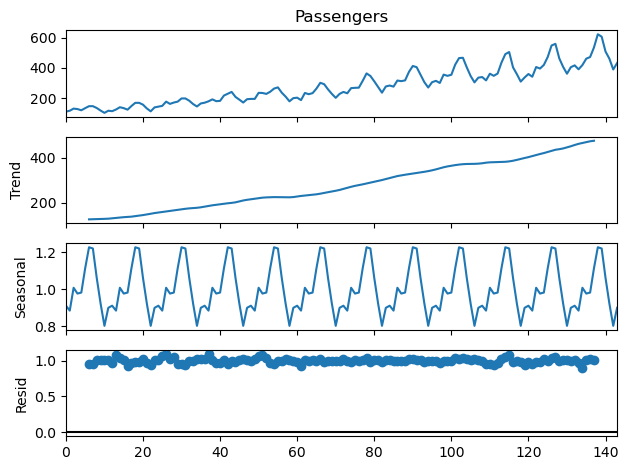

In [8]:
result = seasonal_decompose(df["Passengers"], model="multiplicative", period=12)

result.plot()
plt.show()

The decomposition shows that the dataset has a clear upward trend and strong yearly seasonality.  
Passenger numbers generally increase over time, and similar seasonal patterns repeat every year.

## 5.2 Passenger Trend Over Time

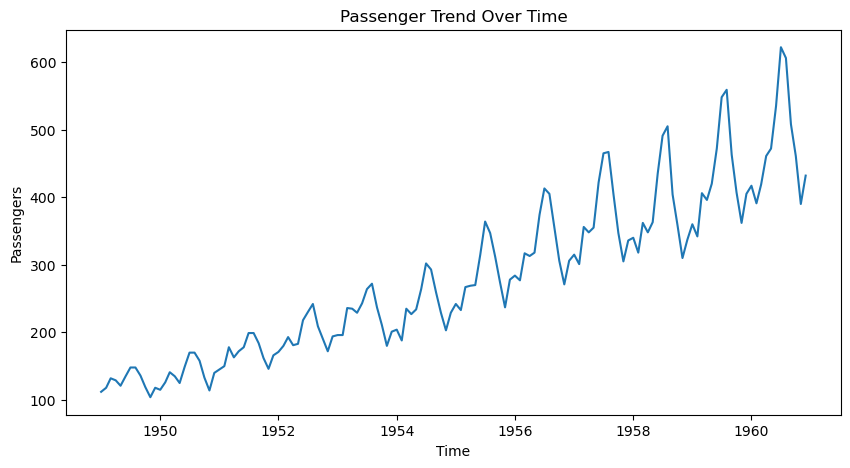

In [9]:
plt.figure(figsize=(10,5))
plt.plot(df["Month"], df["Passengers"])
plt.title("Passenger Trend Over Time")
plt.xlabel("Time")
plt.ylabel("Passengers")
plt.show()

The time series plot clearly shows an increasing trend.  
Passenger numbers rise over the years, which means the series is not stationary.

## 5.3 Distribution of Passenger Counts

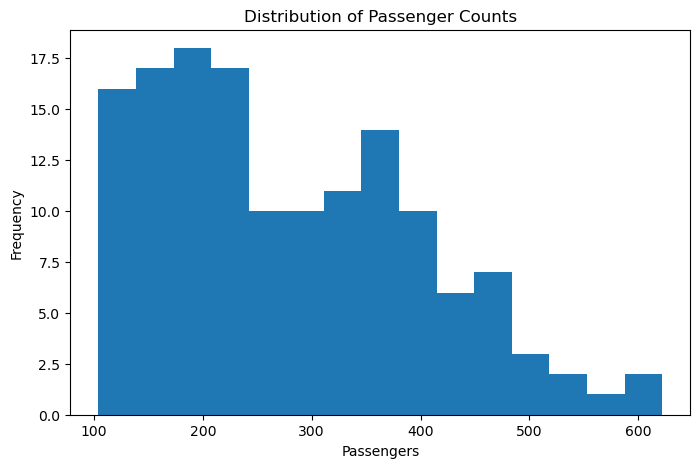

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df["Passengers"], bins=15)
plt.title("Distribution of Passenger Counts")
plt.xlabel("Passengers")
plt.ylabel("Frequency")
plt.show()

The histogram shows that lower passenger values appear more often in the earlier years, while higher passenger values appear later as the trend increases.

## 5.4 Boxplot of Passenger Counts

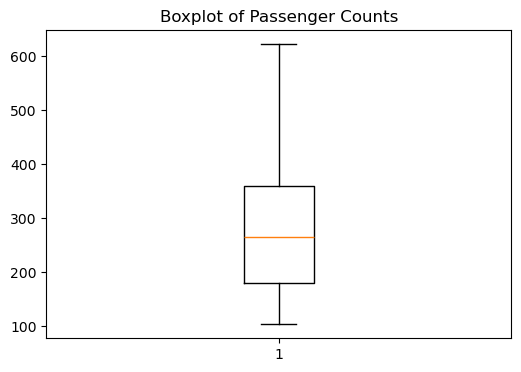

In [11]:
plt.figure(figsize=(6,4))
plt.boxplot(df["Passengers"])
plt.title("Boxplot of Passenger Counts")
plt.show()

The boxplot helps check the spread of passenger numbers.  
There are high values, but they are expected because the series grows over time.

## 5.5 Correlation Analysis

I also check the correlation between passengers and time-based variables.

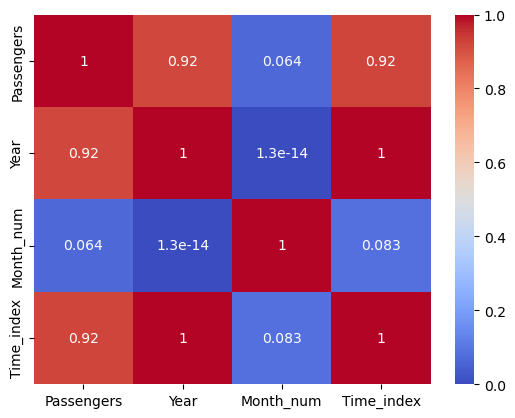

In [12]:
corr = df[["Passengers", "Year", "Month_num", "Time_index"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

The correlation heatmap shows a strong relationship between passenger numbers and time-related variables such as year and time index.  
This supports the idea that there is a strong upward trend in the dataset.

## 6. Modeling

In this project, I use two classical models:

1. ARIMA  
2. Linear Regression  

These models are compared using RMSE, MAPE, and R².

## 6.1 Model 1: ARIMA

ARIMA is a classical time series model.  
I use ARIMA(1,1,1) as a simple baseline model to forecast future passenger numbers.

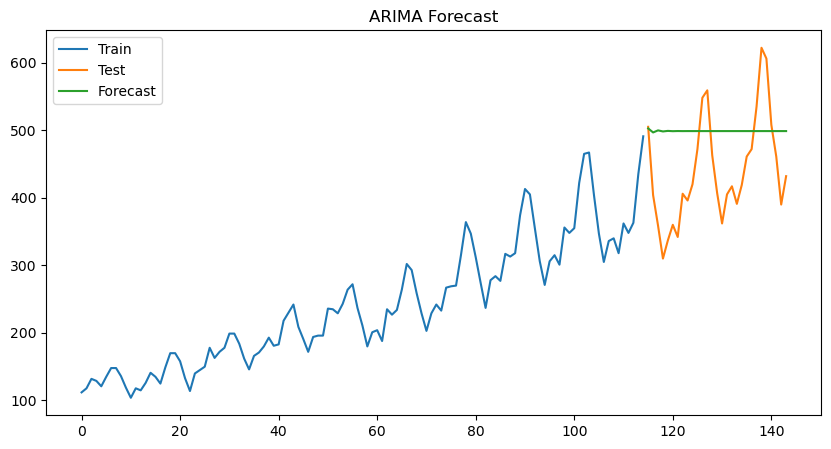

In [13]:
# 
# MODELLING
# 

#model1---------------------
ts = df["Passengers"]
train_ts = train["Passengers"]
test_ts = test["Passengers"]

model = ARIMA(train_ts, order=(1,1,1))
model_fit = model.fit()
forecast = model_fit.forecast(steps=len(test_ts))

plt.figure(figsize=(10,5))

plt.plot(train_ts, label="Train")
plt.plot(test_ts, label="Test")
plt.plot(forecast, label="Forecast")

plt.legend()
plt.title("ARIMA Forecast")
plt.show()

The ARIMA forecast gives a general prediction, but it does not fully capture the strong seasonal pattern in the test period.  
This may reduce its performance because the dataset has clear yearly seasonality.

## 6.2 Model 2: Linear Regression

For the second model, I use Linear Regression with `Time_index` as the input feature.  
The purpose is to model the general upward trend in passenger numbers.

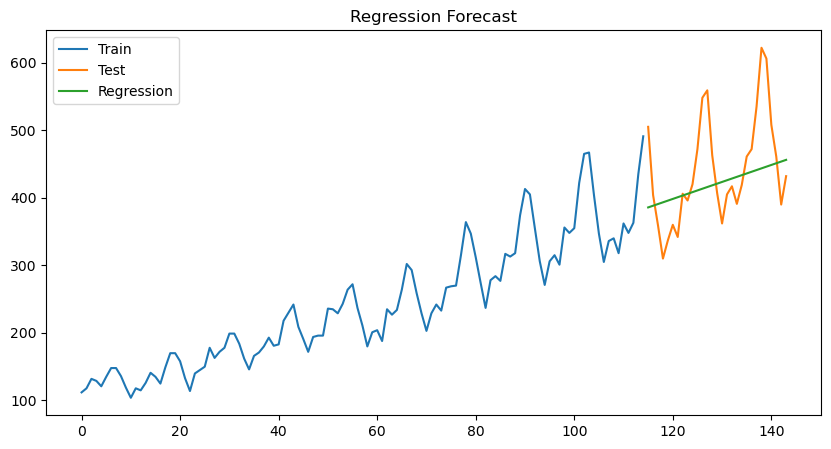

In [14]:
#model2-------------------------
X_train = train[["Time_index"]]
y_train = train["Passengers"]

X_test = test[["Time_index"]]
y_test = test["Passengers"]

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

plt.figure(figsize=(10,5))

plt.plot(train["Time_index"], y_train, label="Train")
plt.plot(test["Time_index"], y_test, label="Test")
plt.plot(test["Time_index"], y_pred, label="Regression")

plt.legend()
plt.title("Regression Forecast")
plt.show()

Linear Regression captures the overall increasing trend better than ARIMA in this project.  
However, it still cannot fully model seasonal ups and downs because it only uses the time index.

## 7. Model Evaluation

I evaluate both models using:

- RMSE  
- MAPE  
- R²  

RMSE shows the average prediction error size.  
MAPE shows the percentage error.  
R² shows how well the model explains the variation in the target variable.

In [15]:
# 
# METRICS
# 

# ARIMA metrics
rmse_arima = np.sqrt(mean_squared_error(test_ts, forecast))
r2_arima = r2_score(test_ts, forecast)
mape_arima = np.mean(np.abs((test_ts - forecast) / test_ts)) * 100

# Regression metrics
rmse_reg = np.sqrt(mean_squared_error(y_test, y_pred))
r2_reg = r2_score(y_test, y_pred)
mape_reg = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("ARIMA RMSE:", rmse_arima)
print("ARIMA R2:", r2_arima)
print("ARIMA MAPE:", mape_arima)

print("Regression RMSE:", rmse_reg)
print("Regression R2:", r2_reg)
print("Regression MAPE:", mape_reg)

ARIMA RMSE: 97.49961965189068
ARIMA R2: -0.5572432748538296
ARIMA MAPE: 21.291348967138678
Regression RMSE: 73.80490236213488
Regression R2: 0.10767914958065461
Regression MAPE: 12.071380134281979


## 8. Model Comparison and Conclusion

Based on the evaluation metrics, the two models can be compared clearly.

In this project, Linear Regression performs better than the simple ARIMA(1,1,1) model according to RMSE and MAPE.  
This means that Linear Regression gives lower prediction errors on the test set.

The main reason is that the dataset has a strong upward trend, and Linear Regression can capture this trend using the time index.  
However, both models have limitations because the data also contains strong seasonality.

Overall, this project satisfies the main requirements:

- Exploratory Data Analysis was performed  
- Time series visualizations were included  
- Two classical models were implemented  
- Forecast visualizations were created  
- Models were compared using RMSE, MAPE, and R²  